C:\Users\Himanshu Sardana\AppData\Local\Temp\ipykernel_10804\825462790.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2020-01-01', periods=36, freq='M')


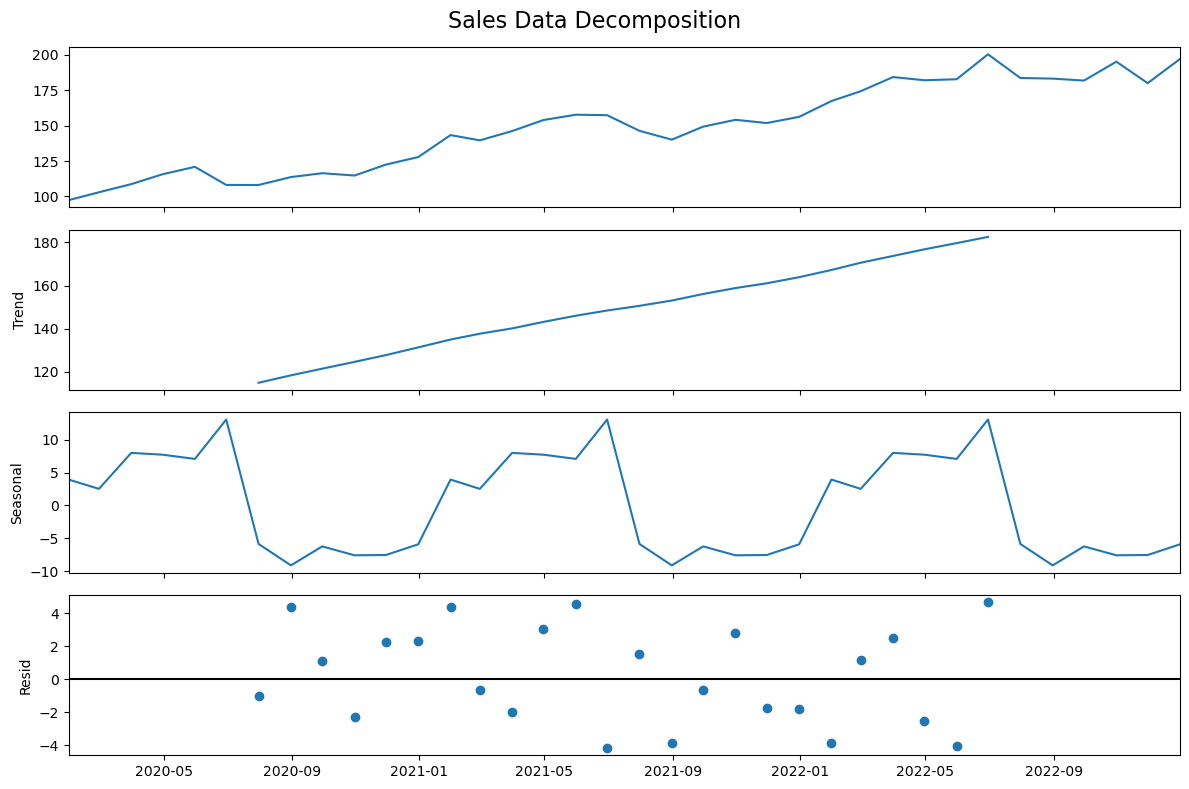

Average monthly growth: 2.78 units
Seasonal peak month: 4


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Generate sample business data (monthly sales)
dates = pd.date_range('2020-01-01', periods=36, freq='M')
trend = np.linspace(100, 200, 36)  # Growing business
seasonal = 10 * np.sin(2 * np.pi * np.arange(36) / 12)  # Seasonal pattern
noise = np.random.normal(0, 5, 36)  # Random fluctuation
sales_data = trend + seasonal + noise

# Create time series
ts = pd.Series(sales_data, index=dates)

# Decompose the time series
decomposition = seasonal_decompose(ts, model='additive')

# Plot components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Sales Data Decomposition', fontsize=16)  # Fixed typo
plt.tight_layout()
plt.show()

# Business insight
avg_growth = (trend[-1] - trend[0]) / 36
peak_month = (np.argmax(seasonal) % 12) + 1  # Ensure month is 1–12

print(f"Average monthly growth: {avg_growth:.2f} units")
print(f"Seasonal peak month: {peak_month}")

In [ ]:
# Business Insight
# - This code helps you simulate, analyze, and forecast sales.
# - You can use it to:
# - Plan inventory and staffing.
# - Set realistic revenue targets.
# - Identify seasonal opportunities.


In [3]:
# 🐍 Business Intelligence Code E-commerce Sales Forecasting
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Simulate realistic e-commerce data
np.random.seed(42)
dates = pd.date_range('2022-01-01', '2024-08-31', freq='D')

# Base sales with growth trend
base_sales = 1000
growth_rate = 0.0005  # 0.05% daily growth
trend = [base_sales * (1 + growth_rate) ** i for i in range(len(dates))]

# Weekly seasonality (weekend boost)
day_of_week_effect = [1.2, 1.1, 1.0, 1.0, 1.1, 1.4, 1.5]  # Mon–Sun
seasonal = [day_of_week_effect[d.weekday()] for d in dates]

# Holiday spikes (Black Friday, Christmas, etc.)
holiday_effect = np.random.choice([1.0, 1.5, 2.0], size=len(dates), p=[0.9, 0.08, 0.02])

# Random noise
noise = np.random.normal(loc=1.0, scale=0.1, size=len(dates))

# Combine all effects
sales = np.array(trend) * np.array(seasonal) * holiday_effect * noise

# Create DataFrame
df = pd.DataFrame({'sales': sales}, index=dates)

# Fit Holt-Winters Exponential Smoothing model
model = ExponentialSmoothing(
    df['sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=7  # Weekly seasonality
)
fitted_model = model.fit()

# Forecast next 30 days
forecast_steps = 30
forecast = fitted_model.forecast(steps=forecast_steps)

# Business metrics
current_monthly_sales = df['sales'].last('30D').sum()
forecasted_monthly_sales = forecast.sum()
growth_projection = (forecasted_monthly_sales / current_monthly_sales - 1) * 100

# Output results
print(f"📊 Current 30-day sales: ${current_monthly_sales:,.0f}")
print(f"📈 Forecasted 30-day sales: ${forecasted_monthly_sales:,.0f}")
print(f"🚀 Projected growth: {growth_projection:.1f}%")

📊 Current 30-day sales: $61,767
📈 Forecasted 30-day sales: $63,153
🚀 Projected growth: 2.2%


C:\Users\Himanshu Sardana\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
C:\Users\Himanshu Sardana\AppData\Local\Temp\ipykernel_10804\1048727863.py:44: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  current_monthly_sales = df['sales'].last('30D').sum()


In [4]:
# Traditional Forecasting Methods
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample monthly sales data



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample monthly sales data
sales_data = [120, 135, 148, 136, 157, 142, 166, 173, 184, 190,
              205, 198, 210, 225, 238, 242, 255, 248, 268, 275]
dates = pd.date_range('2024-01-01', periods=len(sales_data), freq='M')
df = pd.DataFrame({'sales': sales_data}, index=dates)

# 1. Simple Moving Average Forecast
def moving_average_forecast(data, window=3):
    ma = data.rolling(window=window).mean()
    next_forecast = data.tail(window).mean()
    return ma, next_forecast

# 2. Exponential Smoothing Forecast
def exponential_smoothing_forecast(data, alpha=0.3):
    result = [data.iloc[0]]  # Initialize with first value
    for i in range(1, len(data)):
        forecast = alpha * data.iloc[i-1] + (1 - alpha) * result[-1]
        result.append(forecast)
    next_forecast = alpha * data.iloc[-1] + (1 - alpha) * result[-1]
    return pd.Series(result, index=data.index), next_forecast

# Apply forecasting methods
ma_3, ma_forecast = moving_average_forecast(df['sales'], window=3)
exp_smooth, exp_forecast = exponential_smoothing_forecast(df['sales'])

# Accuracy metric: Mean Absolute Error (MAE)
def calculate_mae(actual, predicted):
    return np.mean(np.abs(actual - predicted))

ma_mae = calculate_mae(df['sales'][3:], ma_3[3:])
exp_mae = calculate_mae(df['sales'][1:], exp_smooth[1:])

# Display results
print("📊 Business Forecasting Results:")
print(f"🧮 Moving Average (3-month) - Next month forecast: ${ma_forecast:.0f}")
print(f"📈 Exponential Smoothing - Next month forecast: ${exp_forecast:.0f}")
print(f"📏 Moving Average MAE: ${ma_mae:.2f}")
print(f"📏 Exponential Smoothing MAE: ${exp_mae:.2f}")

# Business decision recommendation
if ma_mae < exp_mae:
    print("✅ Recommendation: Use Moving Average for stable trend business")
else:
    print("✅ Recommendation: Use Exponential Smoothing for dynamic business")
    

📊 Business Forecasting Results:
🧮 Moving Average (3-month) - Next month forecast: $264
📈 Exponential Smoothing - Next month forecast: $255
📏 Moving Average MAE: $8.41
📏 Exponential Smoothing MAE: $23.65
✅ Recommendation: Use Moving Average for stable trend business


C:\Users\Himanshu Sardana\AppData\Local\Temp\ipykernel_10804\1673351403.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range('2024-01-01', periods=len(sales_data), freq='M')


13:09:56 - cmdstanpy - INFO - Chain [1] start processing
13:09:56 - cmdstanpy - INFO - Chain [1] done processing


📊 Business Insights:
✅ Current 30-day average users: 14,515
📈 Forecasted 30-day average users: 14,693
🚀 Expected growth rate: 1.2%
📅 Weekly seasonality peak: 2023-02-27
⚠️ Average forecast uncertainty: ±778 users


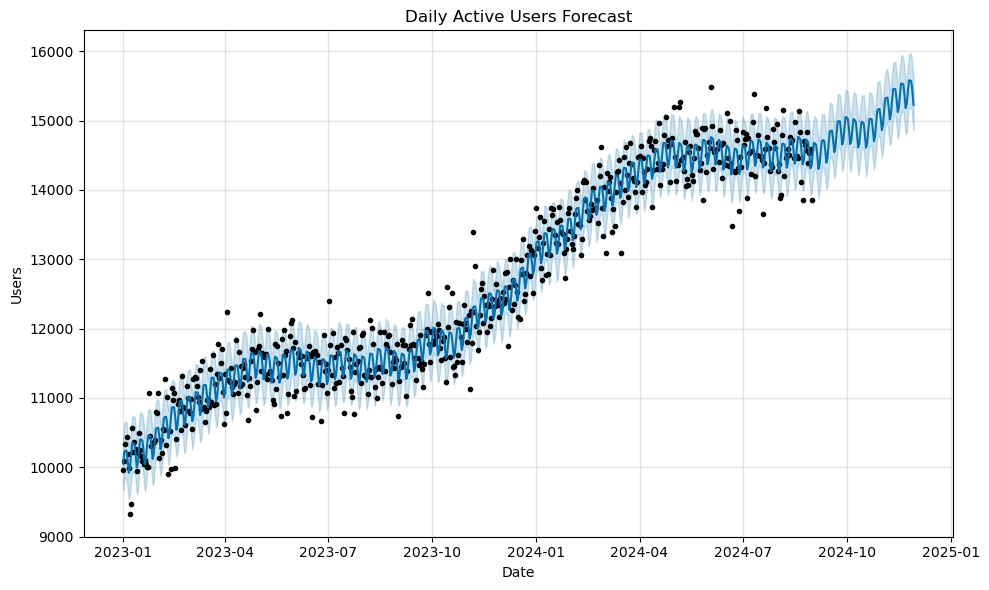

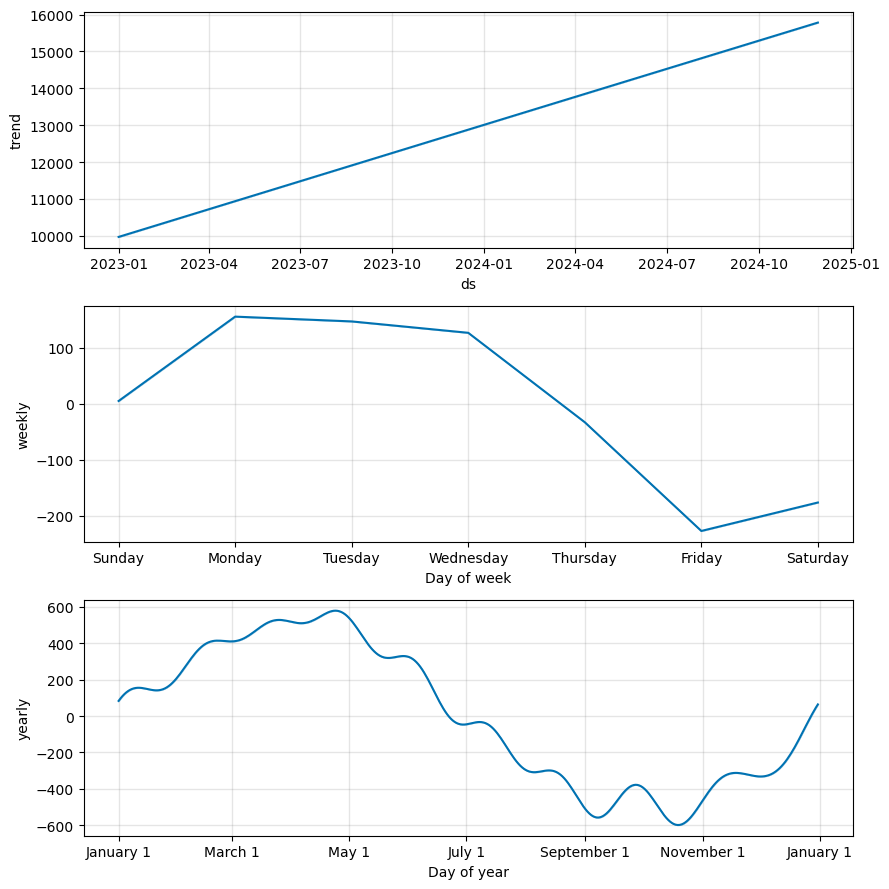

In [8]:
#modern Forcasting Methods
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

# Simulate daily active users for a SaaS company
dates = pd.date_range('2023-01-01', '2024-08-31', freq='D')
base_users = 10000
growth = np.linspace(0, 0.5, len(dates))  # 50% growth over time
seasonal = 500 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25)  # Annual cycle
weekly = 200 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)  # Weekly cycle
noise = np.random.normal(0, 300, len(dates))  # Random variation

# Combine all effects
users = base_users * (1 + growth) + seasonal + weekly + noise

# Prepare data for Prophet
df = pd.DataFrame({
    'ds': dates,  # Prophet requires 'ds' for dates
    'y': users    # Prophet requires 'y' for target variable
})

# Initialize Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,     # Controls trend flexibility
    seasonality_prior_scale=10.0      # Controls seasonality strength
)

# Optional: Add custom holidays or events
# holidays = pd.DataFrame({
#     'holiday': 'product_launch',
#     'ds': pd.to_datetime(['2023-06-15', '2024-03-20']),
#     'lower_window': 0,
#     'upper_window': 7,
# })
# model.add_country_holidays(country_name='US')
# model.add_regressor('holiday')  # If using custom regressors

# Fit the model
model.fit(df)

# Create future dataframe (90 days ahead)
future = model.make_future_dataframe(periods=90)

# Generate forecast
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title('Daily Active Users Forecast')
plt.xlabel('Date')
plt.ylabel('Users')
plt.tight_layout()

# Plot forecast components (trend, weekly, yearly)
components_fig = model.plot_components(forecast)
plt.tight_layout()

# Business metrics
latest_actual = df['y'].iloc[-30:].mean()  # Last 30 days average
forecast_future = forecast['yhat'].iloc[-90:-60].mean()  # Next 30 days average
growth_rate = (forecast_future / latest_actual - 1) * 100

# Uncertainty analysis
confidence_interval = forecast['yhat_upper'] - forecast['yhat_lower']
avg_uncertainty = confidence_interval.iloc[-90:-60].mean()

# Display insights
print("📊 Business Insights:")
print(f"✅ Current 30-day average users: {latest_actual:,.0f}")
print(f"📈 Forecasted 30-day average users: {forecast_future:,.0f}")
print(f"🚀 Expected growth rate: {growth_rate:.1f}%")
peak_index = forecast['weekly'].idxmax()
peak_date = forecast.loc[peak_index, 'ds'].date()
print(f"📅 Weekly seasonality peak: {peak_date}")
print(f"⚠️ Average forecast uncertainty: ±{avg_uncertainty:,.0f} users")

📊 Dataset Overview:
📅 Date range: 2024-01-01 to 2024-12-31
🔢 Total records: 366
📈 Target variable statistics:
count    366.000000
mean     551.946537
std       41.664513
min      434.271033
25%      525.934821
50%      551.701456
75%      575.486987
max      735.896208
Name: y, dtype: float64


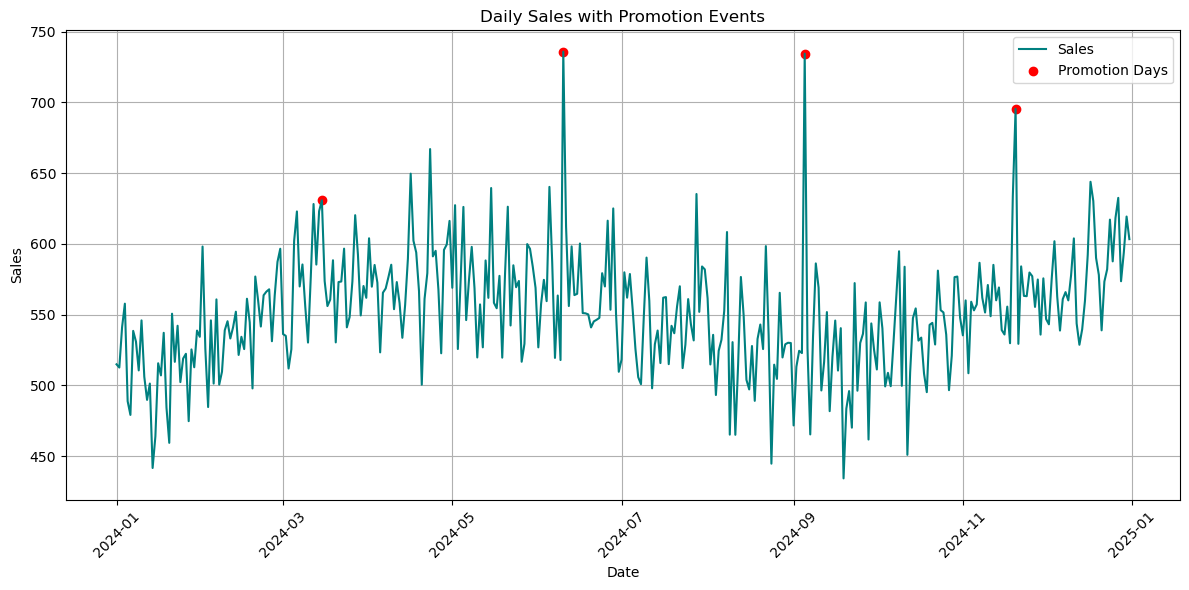

14:01:20 - cmdstanpy - INFO - Chain [1] start processing
14:01:20 - cmdstanpy - INFO - Chain [1] done processing



📏 Business Accuracy Metrics:
✅ Mean Absolute Error (MAE): 44.38
✅ Mean Absolute Percentage Error (MAPE): nan%

📈 Business Forecast:
📊 Current 30-day average: 581
📊 Forecasted 30-day average: 502
🚀 Expected growth: -13.6%


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

def business_forecasting_pipeline():
    """
    Complete business forecasting pipeline with simulated sales data and promotion flags.
    """

    # Step 1: Simulate Daily Sales Data with Promotion Events
    np.random.seed(42)
    dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')

    base_sales = 500
    trend = np.linspace(0, 100, len(dates))  # gradual growth
    seasonal = 50 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25)  # yearly seasonality
    weekly = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)  # weekly pattern
    noise = np.random.normal(loc=0, scale=30, size=len(dates))  # random fluctuations

    promo_dates = pd.to_datetime(['2024-03-15', '2024-06-10', '2024-09-05', '2024-11-20'])
    promo_flag = dates.isin(promo_dates).astype(int)
    promo_boost = promo_flag * 150  # sales spike during promotions

    sales = base_sales + trend + seasonal + weekly + noise + promo_boost

    df = pd.DataFrame({
        'ds': dates,
        'y': sales,
        'promotion': promo_flag
    })

    # Step 2: Exploratory Data Analysis
    print("📊 Dataset Overview:")
    print(f"📅 Date range: {df['ds'].min().date()} to {df['ds'].max().date()}")
    print(f"🔢 Total records: {len(df)}")
    print(f"📈 Target variable statistics:")
    print(df['y'].describe())

    # Step 3: Visual Analysis
    plt.figure(figsize=(12, 6))
    plt.plot(df['ds'], df['y'], label='Sales', color='teal')
    plt.scatter(df[df['promotion'] == 1]['ds'], df[df['promotion'] == 1]['y'], color='red', label='Promotion Days')
    plt.title('Daily Sales with Promotion Events')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Step 4: Train-Test Split (80-20)
    split_point = int(len(df) * 0.8)
    train_data = df.iloc[:split_point]
    test_data = df.iloc[split_point:]

    # Step 5: Model Training (Prophet with Promotion Regressor)
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    model.add_regressor('promotion')
    model.fit(train_data)

    # Step 6: Prediction on Test Set
    future_test = test_data[['ds', 'promotion']]
    forecast_test = model.predict(future_test)

    # Step 7: Business Metrics
    mae = mean_absolute_error(test_data['y'], forecast_test['yhat'])
    mape = np.mean(np.abs((test_data['y'] - forecast_test['yhat']) / test_data['y'])) * 100

    print("\n📏 Business Accuracy Metrics:")
    print(f"✅ Mean Absolute Error (MAE): {mae:.2f}")
    print(f"✅ Mean Absolute Percentage Error (MAPE): {mape:.1f}%")

    # Step 8: Future Forecast (30 days ahead)
    future_periods = 30
    future_df = model.make_future_dataframe(periods=future_periods)
    future_df['promotion'] = future_df['ds'].isin(promo_dates).astype(int)
    future_forecast = model.predict(future_df)

    # Step 9: Business Insights
    current_avg = df['y'].tail(30).mean()
    forecast_avg = future_forecast['yhat'].tail(30).mean()
    growth_rate = (forecast_avg / current_avg - 1) * 100

    print("\n📈 Business Forecast:")
    print(f"📊 Current 30-day average: {current_avg:,.0f}")
    print(f"📊 Forecasted 30-day average: {forecast_avg:,.0f}")
    print(f"🚀 Expected growth: {growth_rate:.1f}%")

    return model, future_forecast, {
        'mae': mae,
        'mape': mape,
        'growth_rate': growth_rate
    }

# ✅ Run the pipeline
model, forecast, metrics = business_forecasting_pipeline()

📊 Dataset Overview:
📅 Date range: 2024-01-01 to 2024-12-31
🔢 Total records: 366
📈 Target variable statistics:
count    366.000000
mean     551.946537
std       41.664513
min      434.271033
25%      525.934821
50%      551.701456
75%      575.486987
max      735.896208
Name: sales, dtype: float64


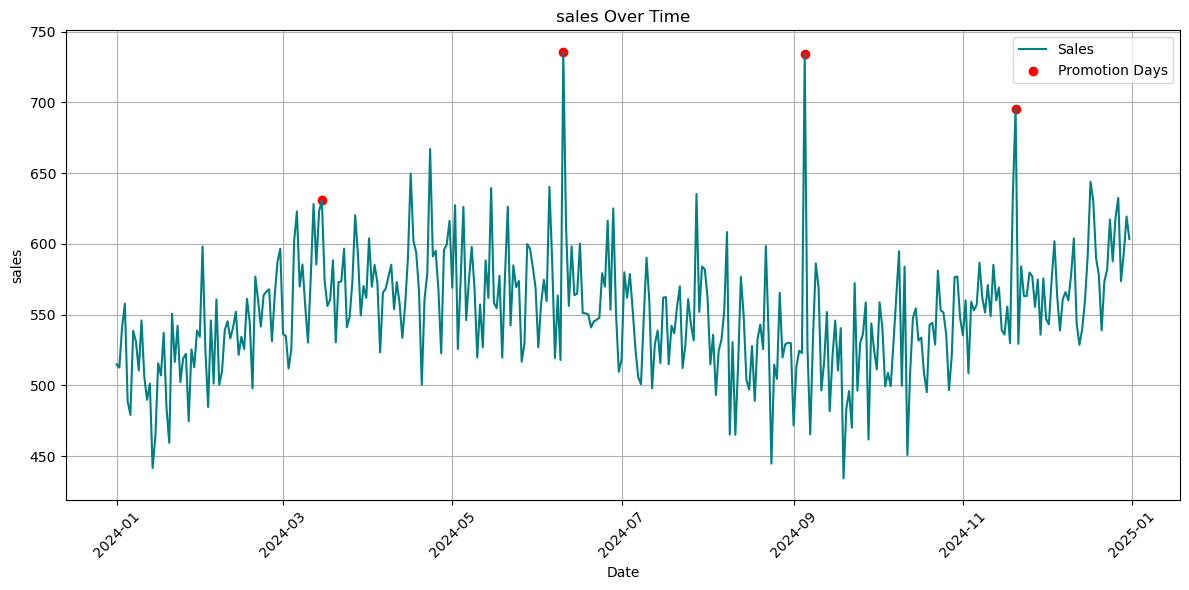

14:14:43 - cmdstanpy - INFO - Chain [1] start processing
14:14:43 - cmdstanpy - INFO - Chain [1] done processing



📏 Business Accuracy Metrics:
✅ Mean Absolute Error (MAE): 44.38
✅ Mean Absolute Percentage Error (MAPE): 7.7%

📈 Business Forecast:
📊 Current 30-day average: 581
📊 Forecasted 30-day average: 502
🚀 Expected growth: -13.6%


In [11]:
# Business Forecasting Pipeline with Synthetic Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

def generate_synthetic_sales_data():
    """
    Simulates daily sales data for one year with trend, seasonality, noise, and promotions.
    """
    np.random.seed(42)
    dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')

    # Components
    base_sales = 500
    trend = np.linspace(0, 100, len(dates))  # gradual growth
    seasonal = 50 * np.sin(2 * np.pi * np.arange(len(dates)) / 365.25)  # yearly seasonality
    weekly = 20 * np.sin(2 * np.pi * np.arange(len(dates)) / 7)  # weekly pattern
    noise = np.random.normal(loc=0, scale=30, size=len(dates))  # random fluctuations

    # Promotion effect
    promo_dates = pd.to_datetime(['2024-03-15', '2024-06-10', '2024-09-05', '2024-11-20'])
    promo_flag = dates.isin(promo_dates).astype(int)
    promo_boost = promo_flag * 150

    # Final sales
    sales = base_sales + trend + seasonal + weekly + noise + promo_boost

    return pd.DataFrame({
        'date': dates,
        'sales': sales,
        'promotion': promo_flag
    })

def business_forecasting_pipeline(data, target_column, date_column, regressor_column=None):
    """
    Complete business forecasting pipeline using Prophet.
    Includes EDA, visualization, model training, evaluation, and future forecasting.
    """
    # Step 1: Data Preparation
    df = data.copy()
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    df = df.dropna(subset=[date_column, target_column])
    df = df.sort_values(date_column)

    # Step 2: Exploratory Data Analysis
    print("📊 Dataset Overview:")
    print(f"📅 Date range: {df[date_column].min().date()} to {df[date_column].max().date()}")
    print(f"🔢 Total records: {len(df)}")
    print(f"📈 Target variable statistics:")
    print(df[target_column].describe())

    # Step 3: Visual Analysis
    plt.figure(figsize=(12, 6))
    plt.plot(df[date_column], df[target_column], label='Sales', color='teal')
    if regressor_column:
        plt.scatter(df[df[regressor_column] == 1][date_column], df[df[regressor_column] == 1][target_column],
                    color='red', label='Promotion Days')
    plt.title(f'{target_column} Over Time')
    plt.xlabel('Date')
    plt.ylabel(target_column)
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Step 4: Train-Test Split
    split_point = int(len(df) * 0.8)
    train_data = df.iloc[:split_point]
    test_data = df.iloc[split_point:]

    # Step 5: Model Training
    prophet_df = train_data[[date_column, target_column]].rename(columns={date_column: 'ds', target_column: 'y'})
    if regressor_column:
        prophet_df[regressor_column] = train_data[regressor_column].values

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False
    )
    if regressor_column:
        model.add_regressor(regressor_column)

    model.fit(prophet_df)

    # Step 6: Prediction on Test Set
    future_test = test_data[[date_column]].rename(columns={date_column: 'ds'})
    if regressor_column:
        future_test[regressor_column] = test_data[regressor_column].values

    forecast_test = model.predict(future_test)

    # Step 7: Business Metrics
    mae = mean_absolute_error(test_data[target_column].values, forecast_test['yhat'].values)
    mape = np.mean(np.abs((test_data[target_column].values - forecast_test['yhat'].values) / test_data[target_column].values)) * 100

    print("\n📏 Business Accuracy Metrics:")
    print(f"✅ Mean Absolute Error (MAE): {mae:.2f}")
    print(f"✅ Mean Absolute Percentage Error (MAPE): {mape:.1f}%")

    # Step 8: Future Forecast
    future_periods = 30
    future_df = model.make_future_dataframe(periods=future_periods)
    if regressor_column:
        promo_dates = df[df[regressor_column] == 1][date_column].unique()
        future_df[regressor_column] = future_df['ds'].isin(promo_dates).astype(int)

    future_forecast = model.predict(future_df)

    # Step 9: Business Insights
    current_avg = df[target_column].tail(30).mean()
    forecast_avg = future_forecast['yhat'].tail(30).mean()
    growth_rate = (forecast_avg / current_avg - 1) * 100

    print("\n📈 Business Forecast:")
    print(f"📊 Current 30-day average: {current_avg:,.0f}")
    print(f"📊 Forecasted 30-day average: {forecast_avg:,.0f}")
    print(f"🚀 Expected growth: {growth_rate:.1f}%")

    return model, future_forecast, {
        'mae': mae,
        'mape': mape,
        'growth_rate': growth_rate
    }

# ✅ Run the pipeline with synthetic data
synthetic_data = generate_synthetic_sales_data()
model, forecast, metrics = business_forecasting_pipeline(
    data=synthetic_data,
    target_column='sales',
    date_column='date',
    regressor_column='promotion'
)